In [4]:
import os
import random
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset

import torchvision
from torchvision import datasets, transforms, models
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)

Device: cpu
Torch: 2.12.0+cpu
Torchvision: 0.27.0+cpu


C:\Users\ivanp\.conda\envs\tfm_clean\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
DATA_PATH = Path(r"C:\Users\ivanp\Desktop\MASTER\2oaño\TFM\archive\casia-webface")
assert DATA_PATH.exists(), f"No existe la ruta: {DATA_PATH}"
print(DATA_PATH)

C:\Users\ivanp\Desktop\MASTER\2oaño\TFM\archive\casia-webface


In [7]:
IMG_SIZE = 112
BATCH_SIZE = 64
EMBEDDING_DIM = 512
EPOCHS = 5
LR = 1e-4

# Para hacer pruebas rápidas sin cargar todo el dataset:
DEBUG_SUBSET = False
DEBUG_MAX_IMAGES = 5000

In [8]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

# Para visualizar pasos individuales
vis_resize = transforms.Resize((IMG_SIZE, IMG_SIZE))
vis_flip = transforms.RandomHorizontalFlip(p=1.0)
to_tensor = transforms.ToTensor()

In [9]:
base_dataset = datasets.ImageFolder(DATA_PATH)
print("Número de clases:", len(base_dataset.classes))
print("Número total de imágenes:", len(base_dataset))
print("Primera clase:", base_dataset.classes[0] if len(base_dataset.classes) > 0 else "N/A")

Número de clases: 10572
Número total de imágenes: 490623
Primera clase: 000000


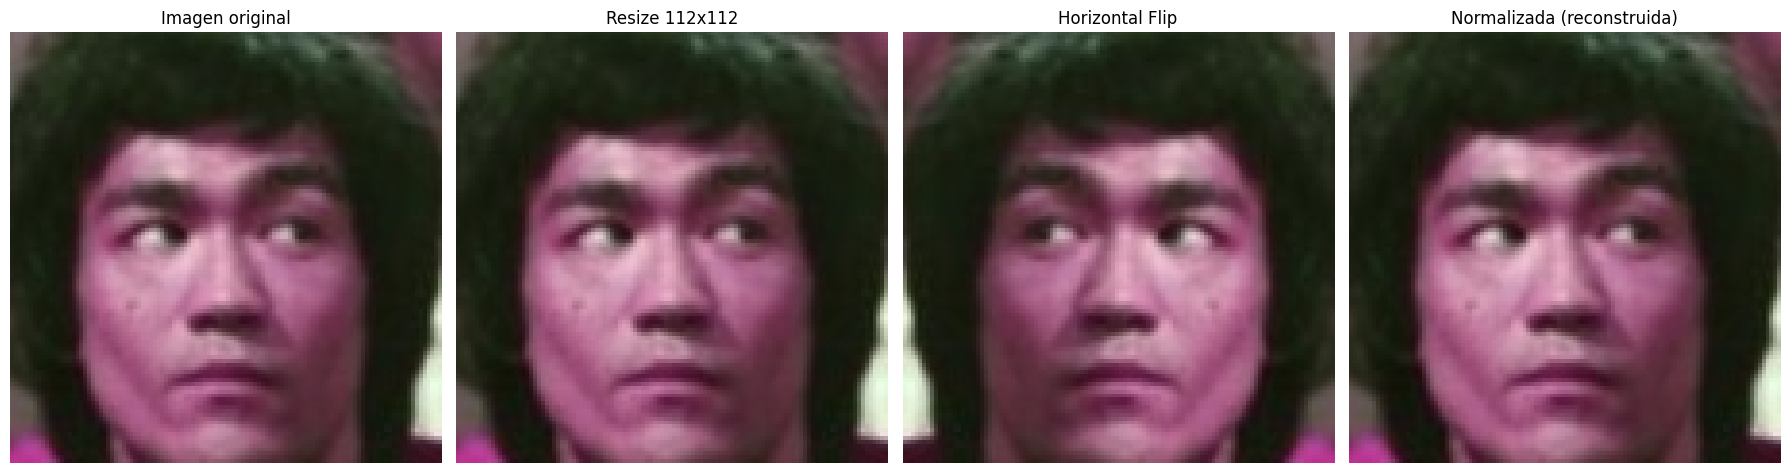

In [11]:
def denormalize(tensor_img):
    x = tensor_img.clone().cpu()
    x = x * 0.5 + 0.5
    return torch.clamp(x, 0, 1)

sample_path, sample_label = base_dataset.samples[0]
img = Image.open(sample_path).convert("RGB")

img_resized = vis_resize(img)
img_flipped = vis_flip(img_resized)
img_normalized = eval_transform(img)
img_normalized_vis = denormalize(img_normalized)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(img)
axes[0].set_title("Imagen original")
axes[0].axis("off")

axes[1].imshow(img_resized)
axes[1].set_title(f"Resize {IMG_SIZE}x{IMG_SIZE}")
axes[1].axis("off")

axes[2].imshow(img_flipped)
axes[2].set_title("Horizontal Flip")
axes[2].axis("off")

axes[3].imshow(np.transpose(img_normalized_vis.numpy(), (1, 2, 0)))
axes[3].set_title("Normalizada (reconstruida)")
axes[3].axis("off")

plt.tight_layout()
plt.show()

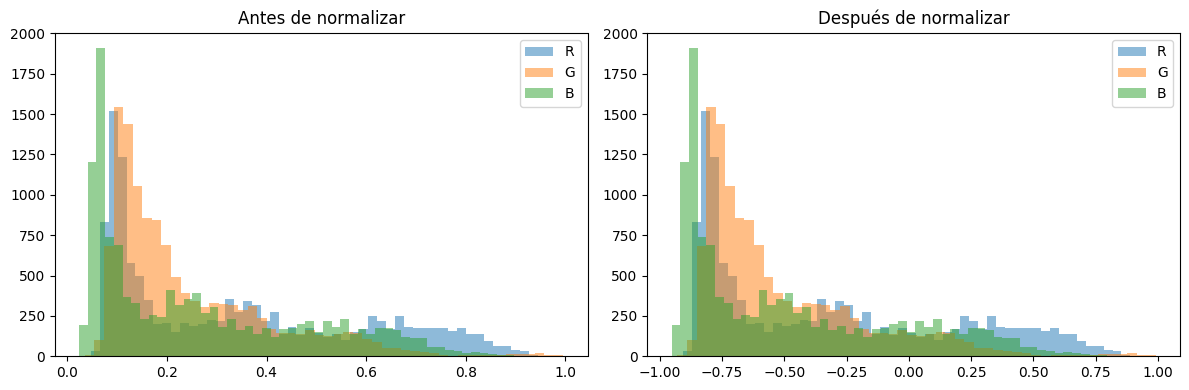

In [12]:
orig_np = np.array(img_resized).astype(np.float32) / 255.0
norm_np = np.transpose(img_normalized.numpy(), (1, 2, 0))  # rango aprox [-1,1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(orig_np[..., 0].ravel(), bins=50, alpha=0.5, label="R")
axes[0].hist(orig_np[..., 1].ravel(), bins=50, alpha=0.5, label="G")
axes[0].hist(orig_np[..., 2].ravel(), bins=50, alpha=0.5, label="B")
axes[0].set_title("Antes de normalizar")
axes[0].legend()

axes[1].hist(norm_np[..., 0].ravel(), bins=50, alpha=0.5, label="R")
axes[1].hist(norm_np[..., 1].ravel(), bins=50, alpha=0.5, label="G")
axes[1].hist(norm_np[..., 2].ravel(), bins=50, alpha=0.5, label="B")
axes[1].set_title("Después de normalizar")
axes[1].legend()

plt.tight_layout()
plt.show()

In [13]:
class_to_indices = defaultdict(list)
for idx, (_, label) in enumerate(base_dataset.samples):
    class_to_indices[label].append(idx)

train_indices = []
gallery_indices = []
probe_indices = []

for cls, indices in class_to_indices.items():
    random.shuffle(indices)
    if len(indices) >= 3:
        gallery_indices.append(indices[0])
        probe_indices.append(indices[1])
        train_indices.extend(indices[2:])
    elif len(indices) == 2:
        gallery_indices.append(indices[0])
        probe_indices.append(indices[1])
    else:
        train_indices.extend(indices)

print("Train:", len(train_indices))
print("Gallery:", len(gallery_indices))
print("Probe:", len(probe_indices))

Train: 469479
Gallery: 10572
Probe: 10572


In [14]:
if DEBUG_SUBSET:
    train_indices = random.sample(train_indices, min(DEBUG_MAX_IMAGES, len(train_indices)))
    gallery_indices = random.sample(gallery_indices, min(DEBUG_MAX_IMAGES // 10, len(gallery_indices)))
    probe_indices = random.sample(probe_indices, min(DEBUG_MAX_IMAGES // 10, len(probe_indices)))
    print("DEBUG activado")
    print("Train:", len(train_indices))
    print("Gallery:", len(gallery_indices))
    print("Probe:", len(probe_indices))

In [15]:
train_dataset_full = datasets.ImageFolder(DATA_PATH, transform=train_transform)
eval_dataset_full = datasets.ImageFolder(DATA_PATH, transform=eval_transform)

train_dataset = Subset(train_dataset_full, train_indices)
gallery_dataset = Subset(eval_dataset_full, gallery_indices)
probe_dataset = Subset(eval_dataset_full, probe_indices)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
gallery_loader = DataLoader(gallery_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
probe_loader = DataLoader(probe_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

In [16]:
class ResNet50Backbone(nn.Module):
    def __init__(self, embedding_dim=512, pretrained=True):
        super().__init__()
        if pretrained:
            weights = models.ResNet50_Weights.IMAGENET1K_V2
        else:
            weights = None
        
        model = models.resnet50(weights=weights)
        self.features = nn.Sequential(*list(model.children())[:-1])
        self.embedding = nn.Linear(2048, embedding_dim)
        self.bn = nn.BatchNorm1d(embedding_dim)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.embedding(x)
        x = self.bn(x)
        x = F.normalize(x, p=2, dim=1)
        return x


In [17]:
class CosFaceHead(nn.Module):
    def __init__(self, in_features, out_features, s=64.0, m=0.35):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(out_features, in_features))
        nn.init.xavier_uniform_(self.weight)
        self.s = s
        self.m = m

    def forward(self, x, labels):
        cosine = F.linear(F.normalize(x), F.normalize(self.weight))
        one_hot = torch.zeros_like(cosine)
        one_hot.scatter_(1, labels.view(-1, 1), 1.0)

        logits = cosine - one_hot * self.m
        logits = logits * self.s
        return logits


In [20]:
class ArcFaceHead(nn.Module):
    def __init__(self, in_features, out_features, s=64.0, m=0.50):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(out_features, in_features))
        nn.init.xavier_uniform_(self.weight)
        self.s = s
        self.m = m

    def forward(self, x, labels):
        cosine = F.linear(F.normalize(x), F.normalize(self.weight))
        cosine = torch.clamp(cosine, -1.0 + 1e-7, 1.0 - 1e-7)
        theta = torch.acos(cosine)
        target_logit = torch.cos(theta + self.m)

        one_hot = torch.zeros_like(cosine)
        one_hot.scatter_(1, labels.view(-1, 1), 1.0)

        logits = cosine * (1 - one_hot) + target_logit * one_hot
        logits = logits * self.s
        return logits

In [19]:
def train_model(backbone, head, train_loader, epochs=5, lr=1e-4):
    backbone = backbone.to(device)
    head = head.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        list(backbone.parameters()) + list(head.parameters()),
        lr=lr
    )

    history = {"loss": []}

    for epoch in range(epochs):
        backbone.train()
        head.train()
        running_loss = 0.0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        for imgs, labels in pbar:
            imgs = imgs.to(device)
            labels = labels.to(device)

            feats = backbone(imgs)
            logits = head(feats, labels)
            loss = criterion(logits, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            pbar.set_postfix(loss=float(loss.item()))

        epoch_loss = running_loss / len(train_loader)
        history["loss"].append(epoch_loss)
        print(f"[Epoch {epoch+1}] loss = {epoch_loss:.4f}")

    return backbone, head, history

In [21]:
backbone_cos = ResNet50Backbone(embedding_dim=EMBEDDING_DIM, pretrained=True)
head_cos = CosFaceHead(in_features=EMBEDDING_DIM, out_features=len(base_dataset.classes), s=64.0, m=0.35)

backbone_cos, head_cos, hist_cos = train_model(
    backbone_cos,
    head_cos,
    train_loader,
    epochs=EPOCHS,
    lr=LR
)



Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\ivanp/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 116MB/s]
Epoch 1/5:   0%|          | 0/7336 [00:00<?, ?it/s]C:\Users\ivanp\.conda\envs\tfm_clean\lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Epoch 1/5: 100%|██████████| 7336/7336 [1:51:25<00:00,  1.10it/s, loss=22.2]


[Epoch 1] loss = 26.6381


Epoch 2/5: 100%|██████████| 7336/7336 [2:01:01<00:00,  1.01it/s, loss=13.9]  


[Epoch 2] loss = 16.1576


...

[Epoch 3] loss = 11.3768


Epoch 4/5: 100%|██████████| 7336/7336 [1:46:27<00:00,  1.15it/s, loss=9.39]


[Epoch 4] loss = 8.9772


Epoch 5/5: 100%|██████████| 7336/7336 [1:47:09<00:00,  1.14it/s, loss=8.02]


[Epoch 5] loss = 7.5170


In [22]:
backbone_arc = ResNet50Backbone(embedding_dim=EMBEDDING_DIM, pretrained=True)
head_arc = ArcFaceHead(in_features=EMBEDDING_DIM, out_features=len(base_dataset.classes), s=64.0, m=0.50)

backbone_arc, head_arc, hist_arc = train_model(
    backbone_arc,
    head_arc,
    train_loader,
    epochs=EPOCHS,
    lr=LR
)

Epoch 1/5: 100%|██████████| 7336/7336 [1:50:40<00:00,  1.10it/s, loss=2.91]


[Epoch 1] loss = 24.0278


Epoch 2/5: 100%|██████████| 7336/7336 [1:44:00<00:00,  1.18it/s, loss=4.89]


[Epoch 2] loss = 4.9258


Epoch 3/5: 100%|██████████| 7336/7336 [1:45:13<00:00,  1.16it/s, loss=2.71]


[Epoch 3] loss = 2.9809


Epoch 4/5: 100%|██████████| 7336/7336 [1:46:49<00:00,  1.14it/s, loss=2.63]


[Epoch 4] loss = 2.9362


Epoch 5/5: 100%|██████████| 7336/7336 [1:45:42<00:00,  1.16it/s, loss=3.12]


[Epoch 5] loss = 2.6473


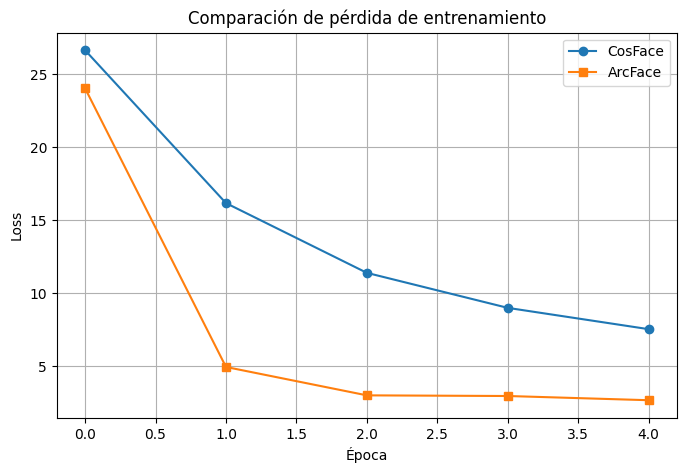

In [23]:
plt.figure(figsize=(8,5))
plt.plot(hist_cos["loss"], marker="o", label="CosFace")
plt.plot(hist_arc["loss"], marker="s", label="ArcFace")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Comparación de pérdida de entrenamiento")
plt.grid(True)
plt.legend()
plt.show()

In [24]:
def extract_embeddings(backbone, loader):
    backbone.eval()
    all_feats = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="Extrayendo embeddings"):
            imgs = imgs.to(device)
            feats = backbone(imgs).cpu()
            all_feats.append(feats)
            all_labels.append(labels)

    feats = torch.cat(all_feats, dim=0)
    labels = torch.cat(all_labels, dim=0)
    return feats, labels

In [25]:
def compute_similarity_matrix(probe_feats, gallery_feats):
    return probe_feats @ gallery_feats.T

def topk_accuracy(sim_matrix, probe_labels, gallery_labels, k=1):
    topk_idx = torch.topk(sim_matrix, k=k, dim=1).indices
    preds = gallery_labels[topk_idx]
    correct = (preds == probe_labels.unsqueeze(1)).any(dim=1).float().mean().item()
    return correct

def cmc_curve(sim_matrix, probe_labels, gallery_labels, max_k=20):
    cmc = []
    for k in range(1, max_k + 1):
        cmc.append(topk_accuracy(sim_matrix, probe_labels, gallery_labels, k=k))
    return cmc

In [26]:
gallery_feats_cos, gallery_labels = extract_embeddings(backbone_cos, gallery_loader)
probe_feats_cos, probe_labels = extract_embeddings(backbone_cos, probe_loader)

sim_cos = compute_similarity_matrix(probe_feats_cos, gallery_feats_cos)

top1_cos = topk_accuracy(sim_cos, probe_labels, gallery_labels, k=1)
top5_cos = topk_accuracy(sim_cos, probe_labels, gallery_labels, k=5)
cmc_cos = cmc_curve(sim_cos, probe_labels, gallery_labels, max_k=20)

print("CosFace Top-1:", top1_cos)
print("CosFace Top-5:", top5_cos)

Extrayendo embeddings: 100%|██████████| 166/166 [01:05<00:00,  2.53it/s]


CosFace Top-1: 0.526485025882721
CosFace Top-5: 0.631195604801178


In [27]:
gallery_feats_arc, gallery_labels = extract_embeddings(backbone_arc, gallery_loader)
probe_feats_arc, probe_labels = extract_embeddings(backbone_arc, probe_loader)

sim_arc = compute_similarity_matrix(probe_feats_arc, gallery_feats_arc)

top1_arc = topk_accuracy(sim_arc, probe_labels, gallery_labels, k=1)
top5_arc = topk_accuracy(sim_arc, probe_labels, gallery_labels, k=5)
cmc_arc = cmc_curve(sim_arc, probe_labels, gallery_labels, max_k=20)

print("ArcFace Top-1:", top1_arc)
print("ArcFace Top-5:", top5_arc)

Extrayendo embeddings: 100%|██████████| 166/166 [01:05<00:00,  2.53it/s]


ArcFace Top-1: 0.0001891789579531178
ArcFace Top-5: 0.0006621263455599546


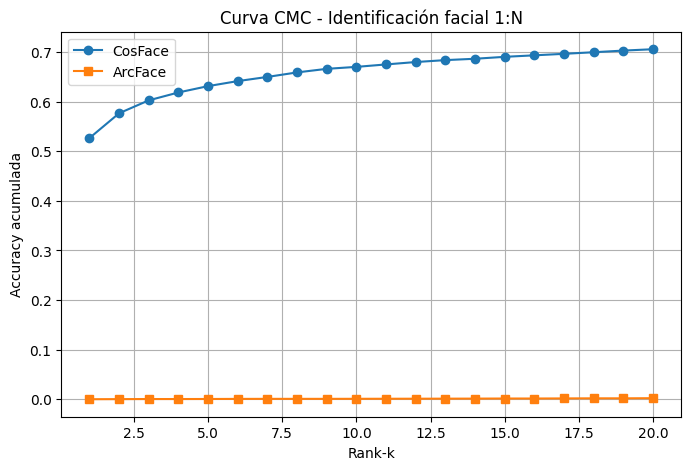

In [28]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(cmc_cos)+1), cmc_cos, marker="o", label="CosFace")
plt.plot(range(1, len(cmc_arc)+1), cmc_arc, marker="s", label="ArcFace")
plt.xlabel("Rank-k")
plt.ylabel("Accuracy acumulada")
plt.title("Curva CMC - Identificación facial 1:N")
plt.grid(True)
plt.legend()
plt.show()

In [29]:
print(f"CosFace -> Top-1: {top1_cos:.4f} | Top-5: {top5_cos:.4f}")
print(f"ArcFace -> Top-1: {top1_arc:.4f} | Top-5: {top5_arc:.4f}")

CosFace -> Top-1: 0.5265 | Top-5: 0.6312
ArcFace -> Top-1: 0.0002 | Top-5: 0.0007


In [30]:
SAVE_DIR = Path("./checkpoints")
SAVE_DIR.mkdir(exist_ok=True)

torch.save(backbone_cos.state_dict(), SAVE_DIR / "backbone_cosface.pth")
torch.save(backbone_arc.state_dict(), SAVE_DIR / "backbone_arcface.pth")

np.save(SAVE_DIR / "cmc_cos.npy", np.array(cmc_cos))
np.save(SAVE_DIR / "cmc_arc.npy", np.array(cmc_arc))

print("Guardado en:", SAVE_DIR.resolve())

Guardado en: C:\Users\ivanp\Desktop\MASTER\2oaño\TFM\checkpoints
